# EBC arena：选一帧，画框，手动微调

在 **hhw9l84** 的 `~/.virtualenvs/rfmapping` kernel 中，从仓库目录运行。

1. 在「选帧」cell 改视频路径和 `frame_index`（**从 0 开始**），运行一次。
2. 在「画框」cell 改 `x_min, x_max, y_min, y_max`，只重跑该 cell 即可细调，不会重新读视频。
3. `zoom_to_box = True` 可以放大框附近。满意后，复制输出的边界参数到 EBC，或运行最后一格保存预览和参数。

坐标与 EBC 一致：原始视频像素，**x 向右、y 向下**；框的顺序为 `(left, right, top, bottom)`。
默认 session 和边界来自 `spatial_cell_analysis.py`；这里只查看单帧，不加载 spike 或 pose。


In [1]:
%matplotlib inline
from io import BytesIO
from pathlib import Path
import json
import subprocess

import numpy as np
from PIL import Image
from matplotlib import pyplot as plt, patheffects
from matplotlib.patches import Rectangle

from Utils.plotting import apply_light_plot_style

apply_light_plot_style()


## 选帧

修改下面的 session / `video_path` 和帧号。按原始视频的解码帧序号取帧，不按 AVI 时间戳跳转；帧号较大时需要等一会儿。


In [6]:
video_path ="/mnt/senzailab/Kai/1.avi"

frame_index = 10  # Zero-based original video frame.

if not isinstance(frame_index, int) or frame_index < 0:
    raise ValueError("frame_index must be a non-negative integer.")

# Basler AVI timestamps can be irregular. Trim by decoded frame ordinal.
decoded = subprocess.run(
    [
        "ffmpeg", "-hide_banner", "-loglevel", "error", "-nostdin",
        "-i", str(video_path), "-map", "0:v:0",
        "-vf", f"trim=start_frame={frame_index}:end_frame={frame_index + 1},setpts=PTS-STARTPTS",
        "-fps_mode", "passthrough", "-frames:v", "1",
        "-f", "image2pipe", "-c:v", "png", "pipe:1",
    ],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE,
)
if decoded.returncode:
    raise RuntimeError(decoded.stderr.decode(errors="replace"))
if not decoded.stdout:
    raise IndexError(f"No decoded frame {frame_index} in {video_path}.")

frame = np.asarray(Image.open(BytesIO(decoded.stdout)).convert("RGB"))
height, width = frame.shape[:2]
print(f"{video_path}\nFrame {frame_index} | {width} × {height} px")


/mnt/senzailab/Kai/1.avi
Frame 10 | 1280 × 1024 px


## 画框：改这四个数，再运行本 cell

`x_min / x_max` 是左 / 右边，`y_min / y_max` 是上 / 下边，单位均为像素，可用小数。


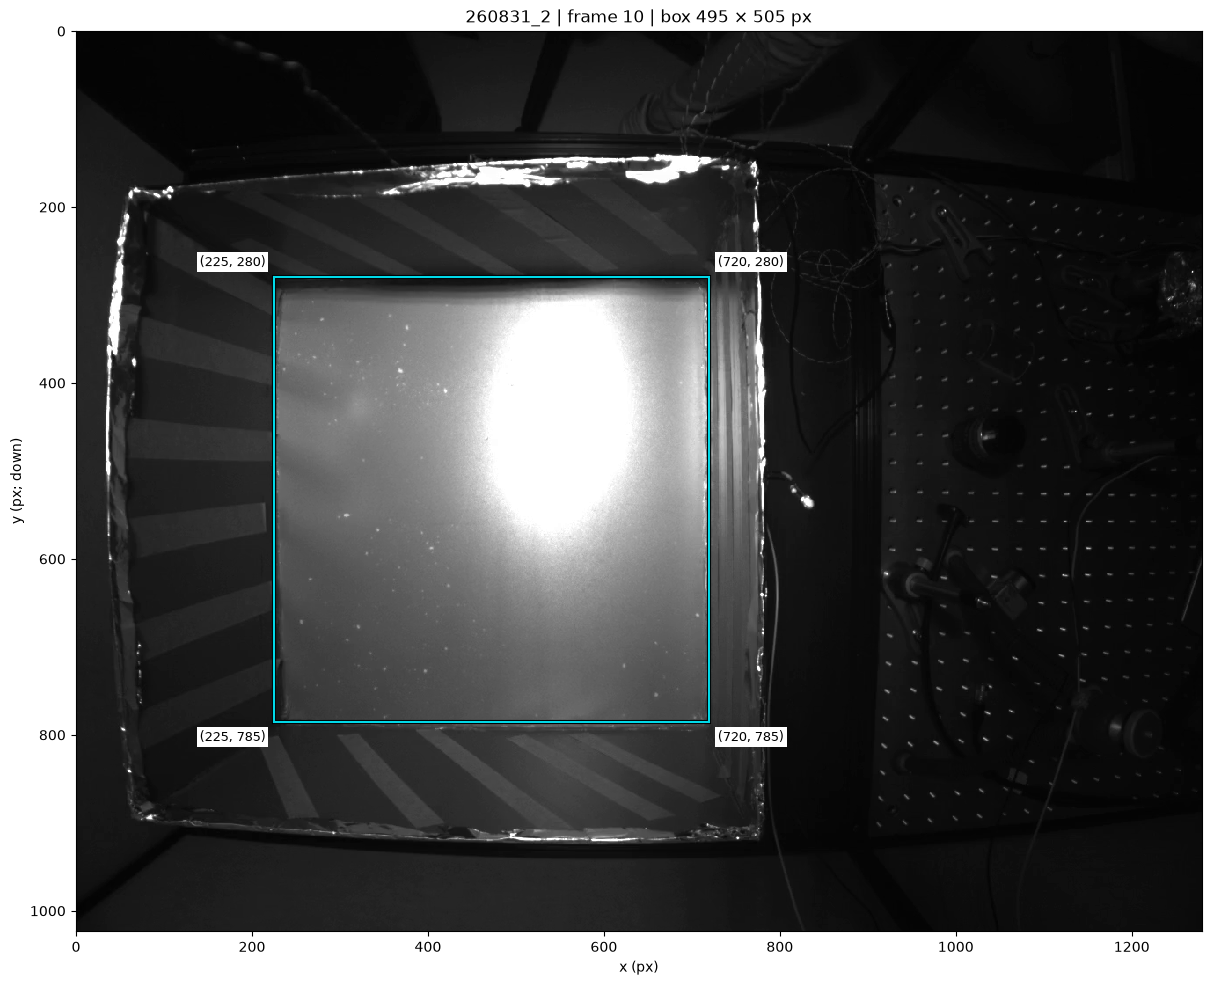

x_min, x_max = 225, 720
y_min, y_max = 280, 785
BASLER_BOUNDS_PX = (225, 720, 280, 785)


In [19]:
x_min, x_max = 225., 720
y_min, y_max = 280., 785.

zoom_to_box = False
padding_px = 60.  # Margin around the box when zoomed in.

if not (0 <= x_min < x_max <= width - 1 and 0 <= y_min < y_max <= height - 1):
    raise ValueError("Bounds must be ordered and inside the original video frame.")

bounds_px = (x_min, x_max, y_min, y_max)
fig, ax = plt.subplots(figsize=(12, 10), layout="constrained", facecolor="white")
ax.set_facecolor("white")
ax.imshow(frame, origin="upper", interpolation="nearest")

box = Rectangle(
    (x_min, y_min), x_max - x_min, y_max - y_min,
    fill=False, edgecolor="#00d9e8", linewidth=1.5,
    path_effects=[patheffects.Stroke(linewidth=3, foreground="black"), patheffects.Normal()],
)
ax.add_patch(box)

for x, y, offset, ha, va in (
    (x_min, y_min, (-6, 6), "right", "bottom"),
    (x_max, y_min, (6, 6), "left", "bottom"),
    (x_min, y_max, (-6, -6), "right", "top"),
    (x_max, y_max, (6, -6), "left", "top"),
):
    ax.annotate(
        f"({x:g}, {y:g})", (x, y), xytext=offset, textcoords="offset points",
        ha=ha, va=va, color="black", fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=2),
    )

if zoom_to_box:
    ax.set_xlim(max(-0.5, x_min - padding_px), min(width - 0.5, x_max + padding_px))
    ax.set_ylim(min(height - 0.5, y_max + padding_px), max(-0.5, y_min - padding_px))
else:
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)

ax.set(
    xlabel="x (px)",
    ylabel="y (px; down)",
    title=f"{session.name} | frame {frame_index} | box {x_max - x_min:g} × {y_max - y_min:g} px",
)
ax.set_aspect("equal")
plt.show()

print(f"x_min, x_max = {x_min:g}, {x_max:g}")
print(f"y_min, y_max = {y_min:g}, {y_max:g}")
print(f"BASLER_BOUNDS_PX = ({x_min:g}, {x_max:g}, {y_min:g}, {y_max:g})")


## 可选：保存当前框

将 `save_preview` 改成 `True` 后运行，保存 PNG 和 JSON 到当前 session 的 `data/spatial_cells/arena_bounds/`。
JSON 记录视频路径、0-based 帧号和原图像素边界；EBC 的边界配置仍由你复制更新。


In [4]:
save_preview = False

if save_preview:
    output_dir = session / "data/spatial_cells/arena_bounds"
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = f"{session.name}_frame{frame_index:06d}_bounds"
    png_path = output_dir / f"{stem}.png"
    json_path = output_dir / f"{stem}.json"

    fig.savefig(png_path, dpi=180, facecolor="white", transparent=False)
    settings = {
        "video_path": str(video_path),
        "frame_index": frame_index,
        "frame_index_base": 0,
        "frame_size_px": {"width": width, "height": height},
        "bounds_order": ["left", "right", "top", "bottom"],
        "bounds_px": list(bounds_px),
        "coordinate_system": "original video pixels; x right, y down",
    }
    json_path.write_text(json.dumps(settings, indent=2) + "\n")
    print(png_path)
    print(json_path)
